<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv" 

In [4]:
import matplotlib.pyplot as plt

In [6]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv(url)

# Display the first few rows of the data to understand its structure
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [7]:
import sqlite3

### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [10]:
#print(df.SOPartFreq.head(50))

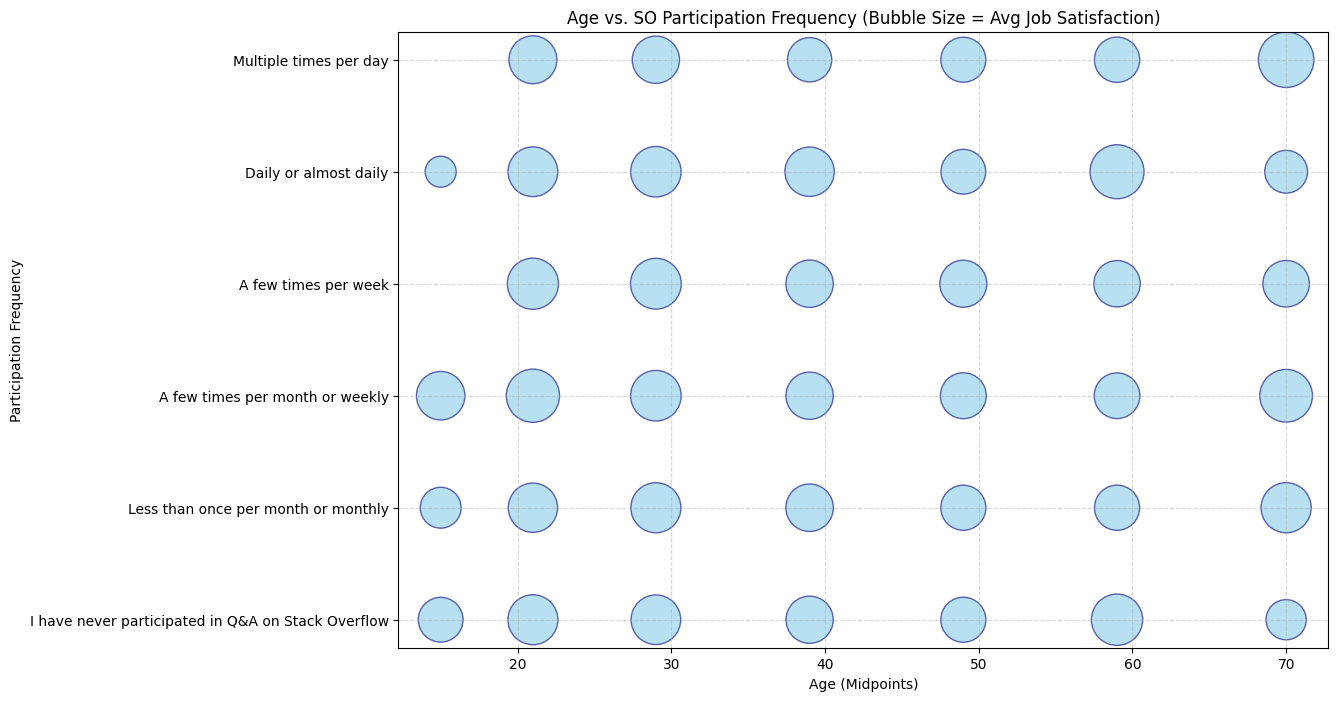

In [19]:
##Write your code here
# Age Midpoints
age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59, '65 years or older': 70
}

# Frequency Mapping (Higher number = More frequent)
freq_map = {
    'I have never participated in Q&A on Stack Overflow': 0,
    'Less than once per month or monthly': 1,
    'A few times per month or weekly': 2,
    'A few times per week': 3,
    'Daily or almost daily': 4,
    'Multiple times per day': 5
}

# Apply mappings
df['Age_Num'] = df['Age'].map(age_map)
df['Freq_Num'] = df['SOPartFreq'].map(freq_map)
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Group data to find the average satisfaction for each Age/Freq pair
# Drop NaNs to ensure clean bubbles
df_bubble = df.dropna(subset=['Age_Num', 'Freq_Num', 'JobSatPoints_6'])
bubble_data = df_bubble.groupby(['Age_Num', 'Freq_Num'])['JobSatPoints_6'].mean().reset_index()

plt.figure(figsize=(12, 8))

plt.scatter(
    x=bubble_data['Age_Num'], 
    y=bubble_data['Freq_Num'], 
    s=bubble_data['JobSatPoints_6'] * 50, 
    alpha=0.6, 
    color='skyblue', 
    edgecolors="navy"
)

# Customizing the Y-Axis to show the actual text again
plt.yticks(ticks=list(freq_map.values()), labels=list(freq_map.keys()))

plt.title('Age vs. SO Participation Frequency (Bubble Size = Avg Job Satisfaction)')
plt.xlabel('Age (Midpoints)')
plt.ylabel('Participation Frequency')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [25]:
#print(df.JobSat.head())

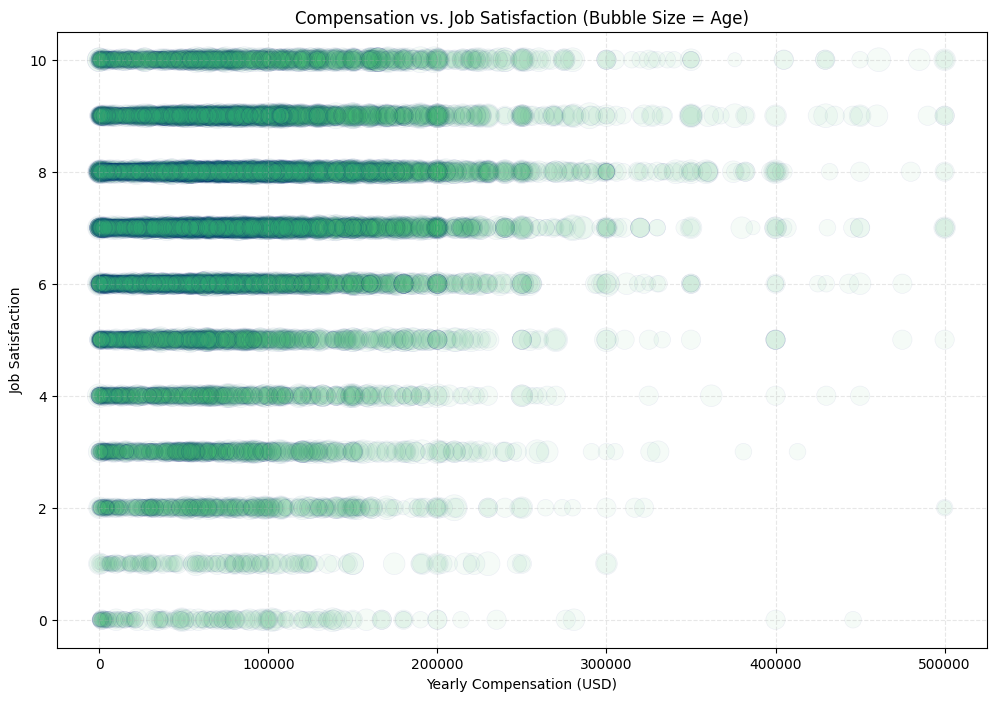

In [32]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
# limit to $500k to prevent extreme outliers from squishing the graph
df_plot = df[df['ConvertedCompYearly'] <= 500000].copy()

# Age to Numeric Midpoints for Bubble Size
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}
df_plot['Age_Numeric'] = df_plot['Age'].map(age_map)

# Drop rows with missing values in target columns
df_plot = df_plot.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age_Numeric'])

plt.figure(figsize=(12, 8))

plt.scatter(
    x=df_plot['ConvertedCompYearly'], 
    y=df_plot['JobSat'], 
    s=df_plot['Age_Numeric'] * 5,  
    alpha=0.05,                   
    color='mediumseagreen', 
    edgecolor='darkblue', 
    linewidth=0.5
)

plt.title('Compensation vs. Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



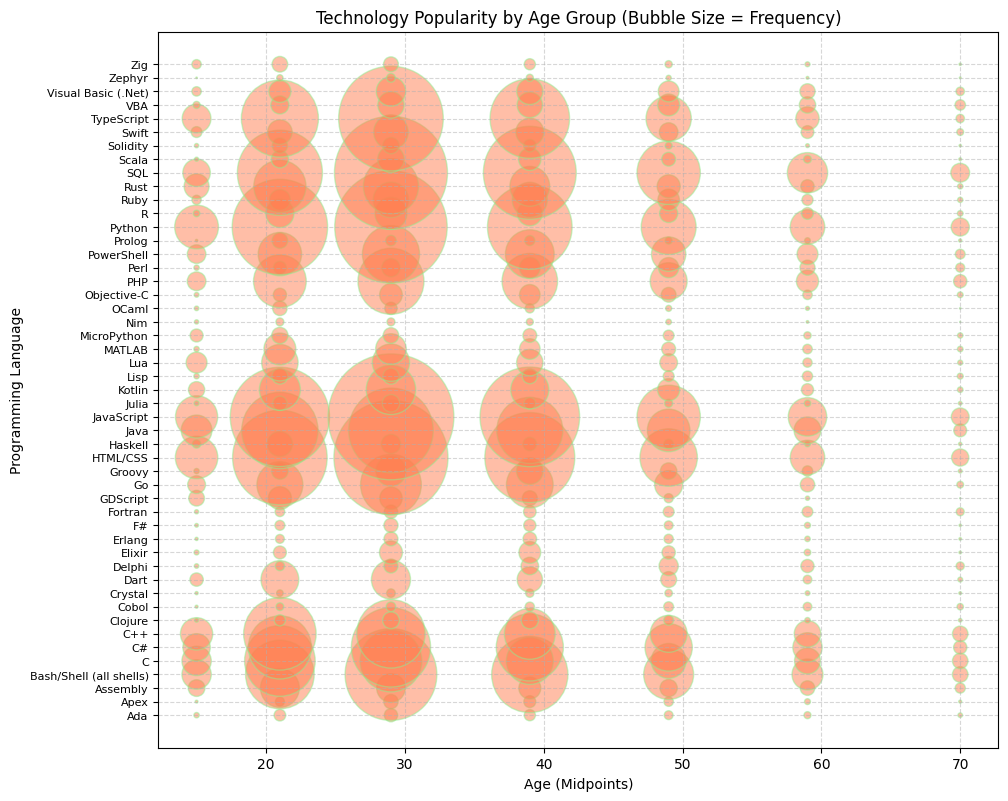

In [52]:
##Write your code here
# Only necessary columns and drop missing values
df_tech = df[['Age', 'LanguageHaveWorkedWith']].dropna()

# Age to numeric midpoints 
age_map = {
    'Under 18 years old': 15, 
    '18-24 years old': 21, 
    '25-34 years old': 29,
    '35-44 years old': 39, 
    '45-54 years old': 49, 
    '55-64 years old': 59, 
    '65 years or older': 70
}
df_tech['Age_Num'] = df_tech['Age'].map(age_map)

# Explode the languages
df_tech['Language'] = df_tech['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_tech.explode('Language')

# Aggregate: how many people in each age group use each language
tech_counts = df_exploded.groupby(['Age_Num', 'Language']).size().reset_index(name='Frequency')

# Filter for Top Languages (to avoid a cluttered graph)
# Top 15 most popular languages overall


plt.figure(figsize=(12, 8))

plt.scatter(
    x=tech_counts['Age_Num'],
    y=tech_counts['Language'],
    s=tech_counts['Frequency'] * 0.6, 
    alpha=0.5,
    color='coral',
    edgecolors='lightgreen'
)
plt.subplots_adjust(left=0.25, bottom=.005, right=0.95, top=0.9)
plt.title('Technology Popularity by Age Group (Bubble Size = Frequency)')
plt.xlabel('Age (Midpoints)')
plt.ylabel('Programming Language')
plt.yticks(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


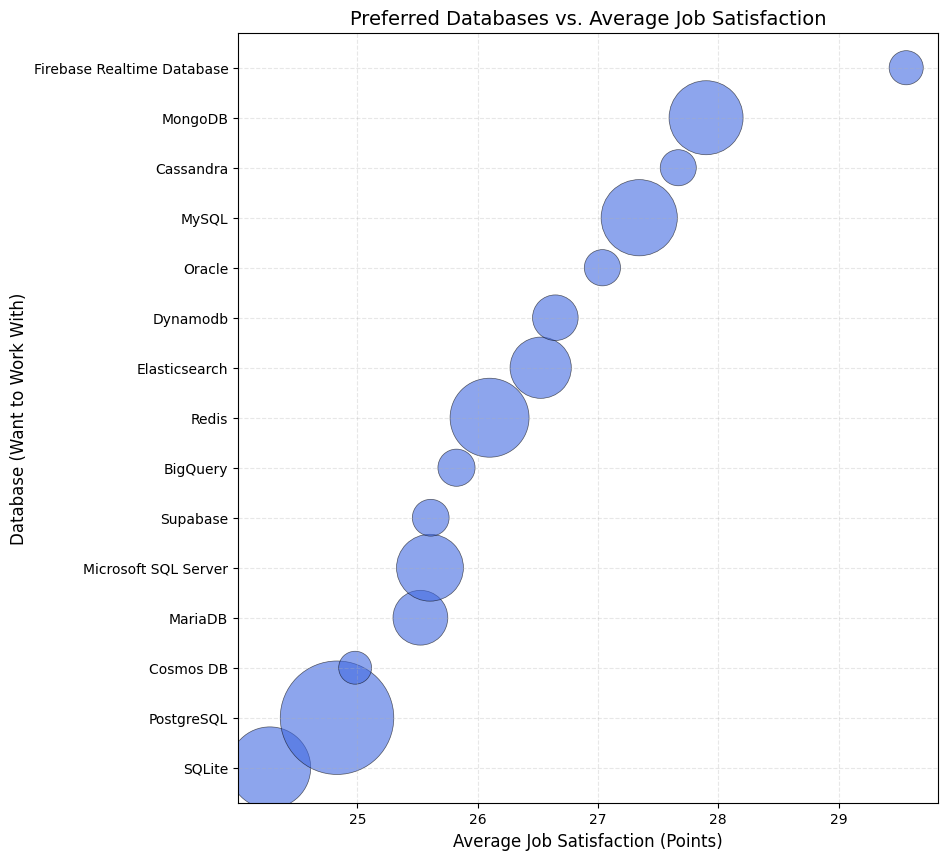

In [53]:
##Write your code here
df_db = df[['DatabaseWantToWorkWith', 'JobSatPoints_6']].dropna()

# Convert satisfaction to numeric
df_db['JobSatPoints_6'] = pd.to_numeric(df_db['JobSatPoints_6'], errors='coerce')

# Explode the semicolon-separated strings into individual rows
df_db['Database'] = df_db['DatabaseWantToWorkWith'].str.split(';')
df_exploded_db = df_db.explode('Database')

# Aggregate
db_stats = df_exploded_db.groupby('Database')['JobSatPoints_6'].agg(['mean', 'count']).reset_index()

# Filter: Top 15 most "wanted" databases for a cleaner visual
top_db_names = db_stats.nlargest(15, 'count')['Database']
db_stats_filtered = db_stats[db_stats['Database'].isin(top_db_names)].sort_values('mean')

plt.figure(figsize=(10, 10))

plt.scatter(
    x=db_stats_filtered['mean'], 
    y=db_stats_filtered['Database'], 
    s=db_stats_filtered['count'] * 0.5, # Size based on number of respondents
    alpha=0.6, 
    color='royalblue', 
    edgecolors='black',
    linewidth=0.5
)

plt.title('Preferred Databases vs. Average Job Satisfaction', fontsize=14)
plt.xlabel('Average Job Satisfaction (Points)', fontsize=12)
plt.ylabel('Database (Want to Work With)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplots_adjust(left=0.2)

plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


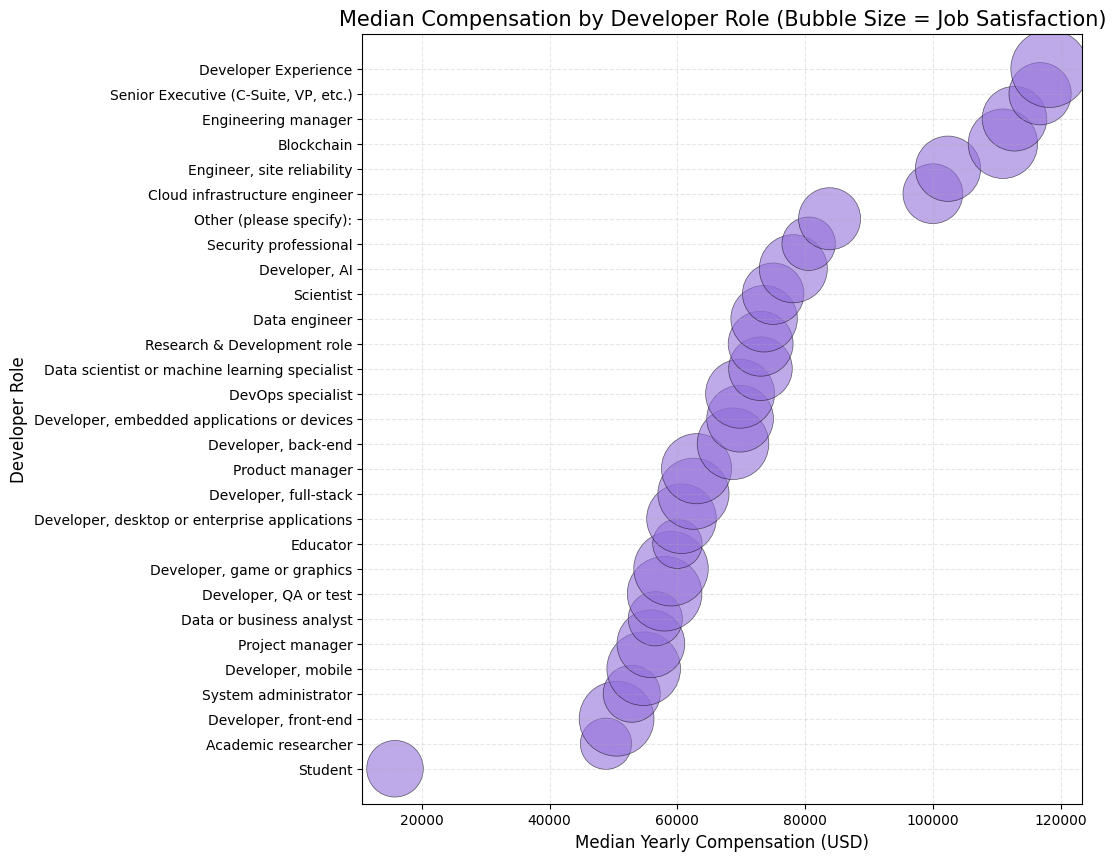

In [55]:
##Write your code here
df_roles = df[['DevType', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Convert compensation and satisfaction to numeric
df_roles['ConvertedCompYearly'] = pd.to_numeric(df_roles['ConvertedCompYearly'], errors='coerce')
df_roles['JobSatPoints_6'] = pd.to_numeric(df_roles['JobSatPoints_6'], errors='coerce')

# Explode the DevType column to handles entries like "Desktop developer;Data scientist"
df_roles['Role'] = df_roles['DevType'].str.split(';')
df_exploded_roles = df_roles.explode('Role')

# Aggregate by Role
role_stats = df_exploded_roles.groupby('Role').agg({
    'ConvertedCompYearly': 'median',
    'JobSatPoints_6': 'mean',
    'Role': 'count'
}).rename(columns={'Role': 'Count'}).reset_index()

# Filter for roles with more than 50 respondents
role_stats = role_stats[role_stats['Count'] > 50].sort_values('ConvertedCompYearly')

plt.figure(figsize=(12, 10))

plt.scatter(
    x=role_stats['ConvertedCompYearly'], 
    y=role_stats['Role'], 
    s=role_stats['JobSatPoints_6'] * 100, # Scale satisfaction for bubble size
    alpha=0.6, 
    color='mediumpurple', 
    edgecolors='black',
    linewidth=0.5
)

plt.title('Median Compensation by Developer Role (Bubble Size = Job Satisfaction)', fontsize=15)
plt.xlabel('Median Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Developer Role', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplots_adjust(left=0.3)

plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


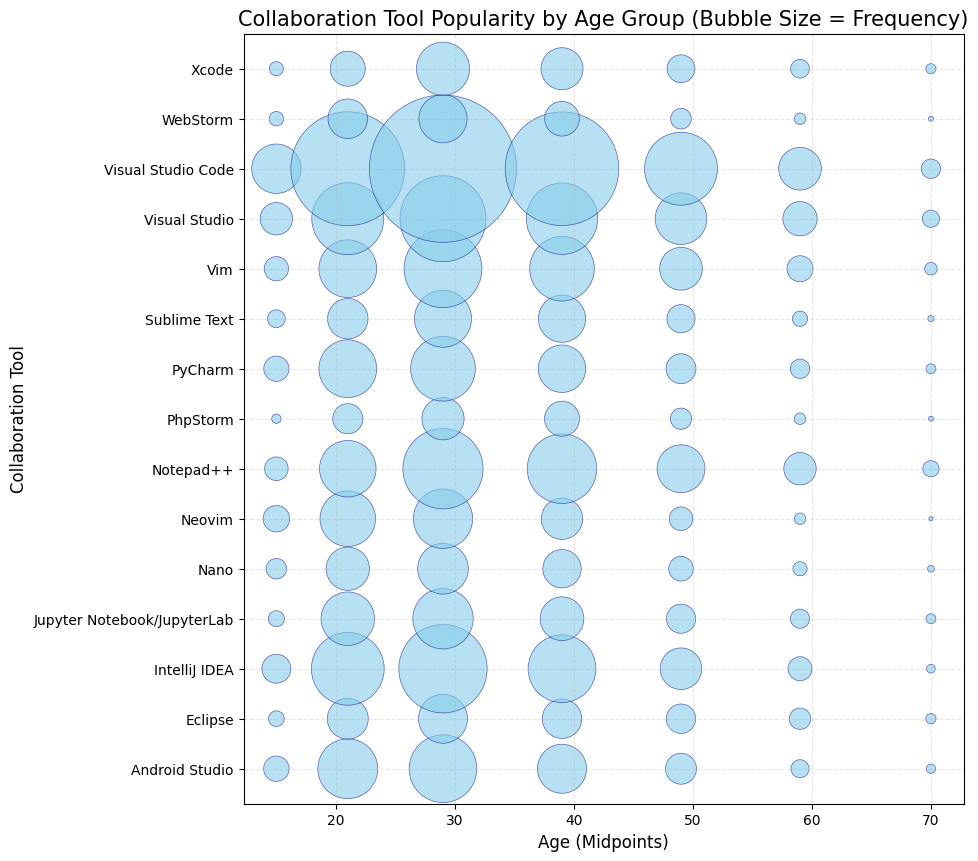

In [56]:
##Write your code here
df_collab = df[['Age', 'NEWCollabToolsHaveWorkedWith']].dropna()

age_map = {
    'Under 18 years old': 15, 
    '18-24 years old': 21, 
    '25-34 years old': 29,
    '35-44 years old': 39, 
    '45-54 years old': 49, 
    '55-64 years old': 59, 
    '65 years or older': 70
}
df_collab['Age_Num'] = df_collab['Age'].map(age_map)

df_collab['Tool'] = df_collab['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_exploded = df_collab.explode('Tool')

tool_counts = df_exploded.groupby(['Age_Num', 'Tool']).size().reset_index(name='Frequency')

top_15_tools = tool_counts.groupby('Tool')['Frequency'].sum().nlargest(15).index
tool_counts_filtered = tool_counts[tool_counts['Tool'].isin(top_15_tools)]

plt.figure(figsize=(12, 10)) 

plt.scatter(
    x=tool_counts_filtered['Age_Num'],
    y=tool_counts_filtered['Tool'],
    s=tool_counts_filtered['Frequency'] * 0.7, 
    alpha=0.6,
    color='skyblue',
    edgecolors='navy',
    linewidth=0.5
)

plt.title('Collaboration Tool Popularity by Age Group (Bubble Size = Frequency)', fontsize=15)
plt.xlabel('Age (Midpoints)', fontsize=12)
plt.ylabel('Collaboration Tool', fontsize=12)

plt.subplots_adjust(left=0.3) # More room for long tool names on the left
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



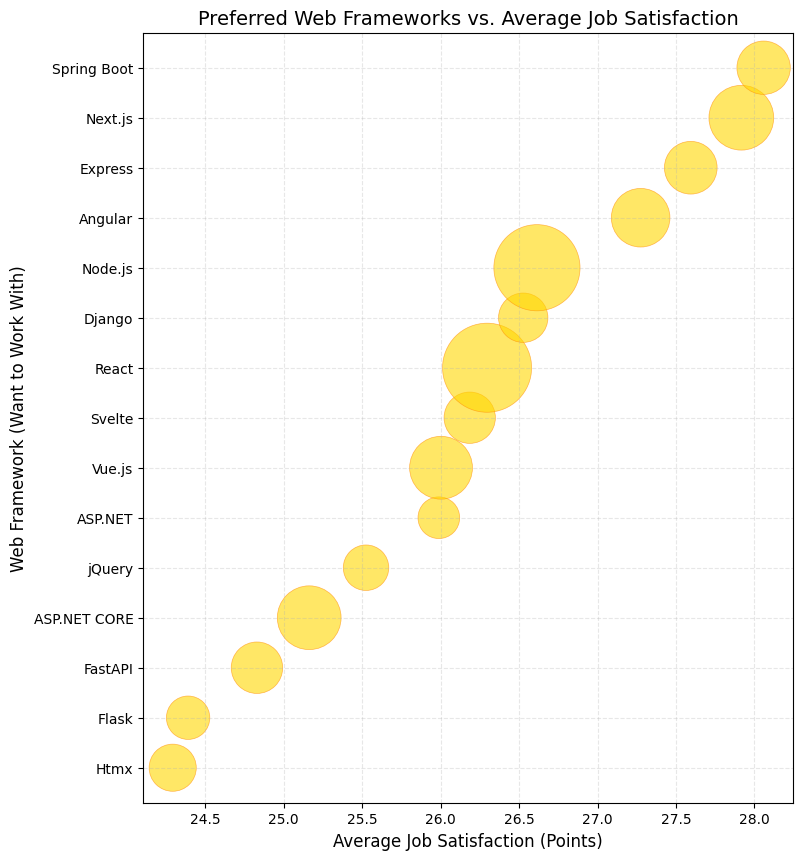

In [57]:
##Write your code here
df_web = df[['WebframeWantToWorkWith', 'JobSatPoints_6']].dropna()

df_web['JobSatPoints_6'] = pd.to_numeric(df_web['JobSatPoints_6'], errors='coerce')

df_web['Framework'] = df_web['WebframeWantToWorkWith'].str.split(';')
df_exploded_web = df_web.explode('Framework')

web_stats = df_exploded_web.groupby('Framework')['JobSatPoints_6'].agg(['mean', 'count']).reset_index()

top_web_names = web_stats.nlargest(15, 'count')['Framework']
web_stats_filtered = web_stats[web_stats['Framework'].isin(top_web_names)].sort_values('mean')

plt.figure(figsize=(10, 10))

plt.scatter(
    x=web_stats_filtered['mean'], 
    y=web_stats_filtered['Framework'], 
    s=web_stats_filtered['count'] * 0.5, 
    alpha=0.6, 
    color='gold', 
    edgecolors='darkorange',
    linewidth=0.5
)

plt.title('Preferred Web Frameworks vs. Average Job Satisfaction', fontsize=14)
plt.xlabel('Average Job Satisfaction (Points)', fontsize=12)
plt.ylabel('Web Framework (Want to Work With)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplots_adjust(left=0.25)

plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



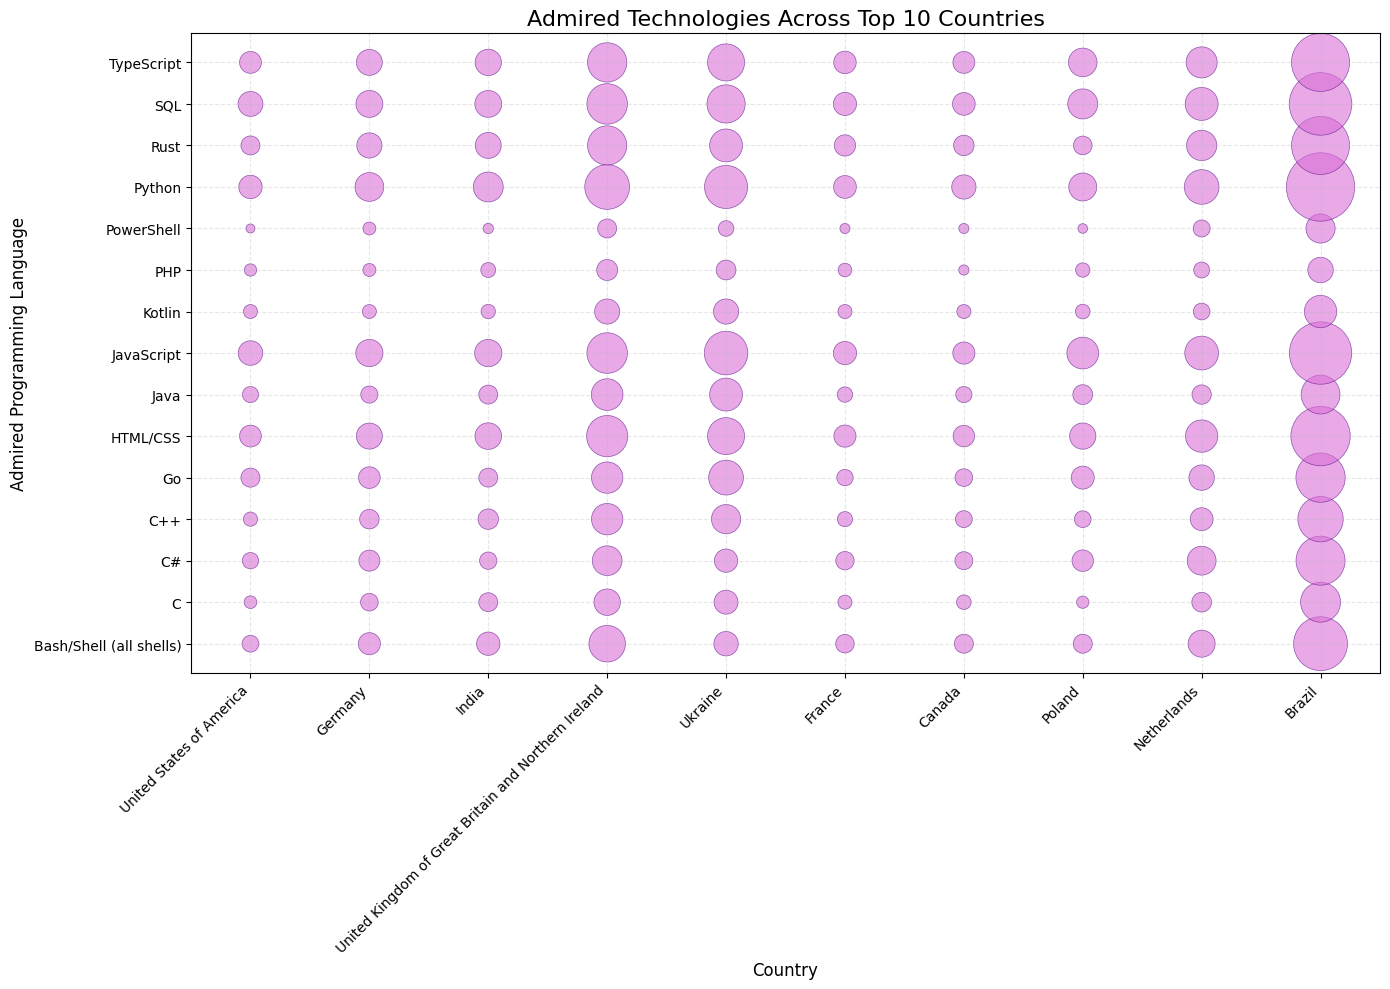

In [59]:
##Write your code here
df_admired = df[['Country', 'LanguageWantToWorkWith']].dropna()

top_countries = df_admired['Country'].value_counts().nlargest(10).index
df_filtered = df_admired[df_admired['Country'].isin(top_countries)].copy()

df_filtered['Language'] = df_filtered['LanguageWantToWorkWith'].str.split(';')
df_exploded = df_filtered.explode('Language')

admired_stats = df_exploded.groupby(['Country', 'Language']).size().reset_index(name='Frequency')

top_langs = admired_stats.groupby('Language')['Frequency'].sum().nlargest(15).index
admired_stats = admired_stats[admired_stats['Language'].isin(top_langs)]

plt.figure(figsize=(14, 10))

plt.scatter(
    x=admired_stats['Country'], 
    y=admired_stats['Language'], 
    s=admired_stats['Frequency'] * 0.5, 
    alpha=0.6, 
    color='orchid', 
    edgecolors='indigo',
    linewidth=0.5
)

plt.title('Admired Technologies Across Top 10 Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Admired Programming Language', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)

plt.xticks(ticks=range(len(top_countries)), labels=top_countries, rotation=45, ha='right')
plt.xlim(-0.5, len(top_countries) - 0.5)

plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
